In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import learning_curve

In [3]:
df = pd.read_csv(
    '../datasets/nutriscore_donnees_propres_final.csv',
    sep=";",
    engine="python"
)

In [4]:
df.dropna()

,code,product_name,nutriscore_score,nutriscore_grade,main_category,energy_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,sodium_100g,fruits-vegetables-legumes_100g
0,112302621,Potiron et vermicelles,3,c,en:cream-of-pumpkin-soups,109.6,0.4,0.2,4.5,1.7,0.80000,0.7,0.280,28.781250
1,112302650,Délice de potiron châtaigne,3,c,en:pumpkin-soups,143.0,0.8,0.4,5.5,2.3,1.10000,0.7,0.304,31.666667
2,112302656,Lié big purSoup mouliné de 10 Légumes,3,c,en:vegetable-soups,150.0,1.2,0.4,4.6,1.4,1.50000,0.9,0.280,24.750000
3,112302660,Soupe potiron et kiri,3,c,en:vegetable-soups,161.0,1.5,1.0,4.9,2.0,0.80000,0.9,0.296,34.312500
4,112302676,Velouté de légumes du soleil,3,c,en:canned-vegetable-soups,147.5,1.7,0.3,3.7,1.4,0.80000,0.9,0.268,29.301250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148839,9876000000064,Chocolat Vegan Amandes Caramel Salé Équitable Bio,36,e,en:plant-milk-chocolates,2267.0,35.0,20.0,55.0,41.0,2.80000,3.0,0.792,0.000000
148840,9898909057345,Pão de Fôrma 35% Integral - Visconti - 400g,3,c,en:wholemeal-sliced-breads,593.5,2.1,0.6,25.0,6.0,2.00000,4.4,0.188,0.000000
148841,990530101020365169,Gâche tranchée,11,d,fr:gaches,931.8,8.0,5.4,32.0,8.7,3.75475,5.4,0.268,0.000000
148842,990530101025174626,Mon haché burger 100% pur boeuf,6,c,en:ground-beef-steaks,775.5,12.0,5.4,0.5,0.5,0.00000,19.0,0.088,0.000000


In [5]:
df.head()

,code,product_name,nutriscore_score,nutriscore_grade,main_category,energy_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,sodium_100g,fruits-vegetables-legumes_100g
0,112302621,Potiron et vermicelles,3,c,en:cream-of-pumpkin-soups,109.6,0.4,0.2,4.5,1.7,0.8,0.7,0.280,28.781250
1,112302650,Délice de potiron châtaigne,3,c,en:pumpkin-soups,143.0,0.8,0.4,5.5,2.3,1.1,0.7,0.304,31.666667
2,112302656,Lié big purSoup mouliné de 10 Légumes,3,c,en:vegetable-soups,150.0,1.2,0.4,4.6,1.4,1.5,0.9,0.280,24.750000
3,112302660,Soupe potiron et kiri,3,c,en:vegetable-soups,161.0,1.5,1.0,4.9,2.0,0.8,0.9,0.296,34.312500
4,112302676,Velouté de légumes du soleil,3,c,en:canned-vegetable-soups,147.5,1.7,0.3,3.7,1.4,0.8,0.9,0.268,29.301250


In [6]:
X = df.drop(columns=['code', 'product_name', 'nutriscore_score', 'nutriscore_grade', 'main_category'])
y = df['nutriscore_score']


X = X.replace({'not-applicable': np.nan, 'not applicable': np.nan, 'not applicable': np.nan})


X = X.apply(pd.to_numeric, errors='coerce')
y = pd.to_numeric(y, errors='coerce')


X = X.reset_index(drop=True)
y = y.reset_index(drop=True)


mask = y.notna()
X = X[mask].reset_index(drop=True)
y = y[mask].reset_index(drop=True)

print("Shape X :", X.shape)
print("Vérification NaN :", X.isnull().sum().sum(), "valeurs manquantes")
print("Types :", X.dtypes.unique())


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])


pipeline.fit(X_train, y_train)


y_pred = pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.3f}")

Shape X : (148844, 9)
Vérification NaN : 0 valeurs manquantes
Types : [dtype('float64')]
MAE  : 0.729
RMSE : 1.713
R²   : 0.969


[learning_curve] Training set sizes: [ 11907  23815  35722  47630  59537  71445  83352  95260 107167 119075]


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 20 concurrent workers.
[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:  1.6min finished


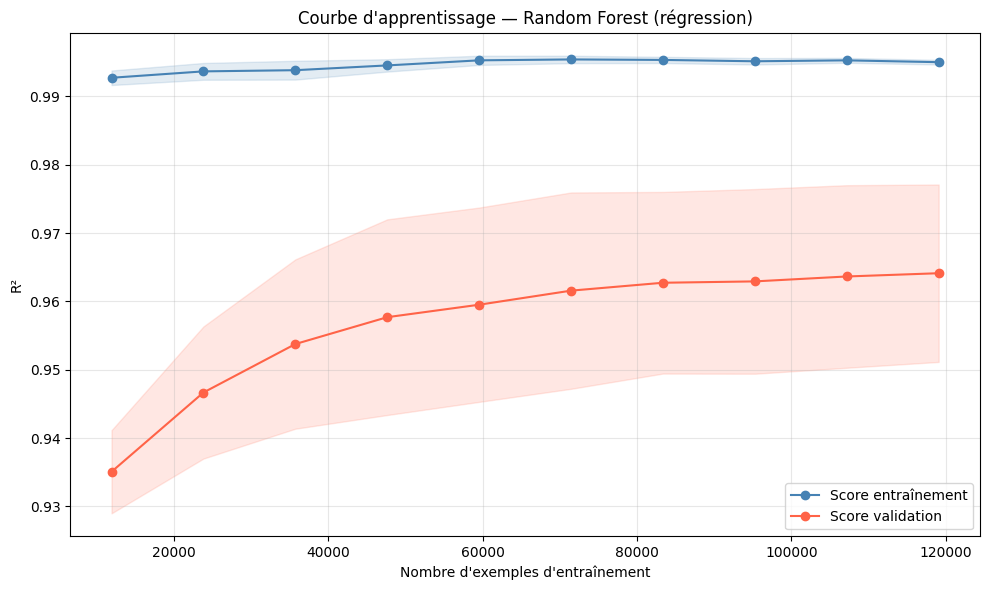

In [7]:
train_sizes, train_scores, val_scores = learning_curve(
    pipeline,
    X, y,
    cv=5,
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1,
    verbose=1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)


plt.figure(figsize=(10, 6))

plt.plot(train_sizes, train_mean, 'o-', color='steelblue', label='Score entraînement')
plt.fill_between(train_sizes,
                 train_mean - train_std,
                 train_mean + train_std,
                 alpha=0.15, color='steelblue')

plt.plot(train_sizes, val_mean, 'o-', color='tomato', label='Score validation')
plt.fill_between(train_sizes,
                 val_mean - val_std,
                 val_mean + val_std,
                 alpha=0.15, color='tomato')

plt.title('Courbe d\'apprentissage — Random Forest (régression)')
plt.xlabel('Nombre d\'exemples d\'entraînement')
plt.ylabel('R²')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()